In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

!pip install gensim

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


In [11]:
import pandas as pd

# Load the dataset from Hugging Face
df = pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/train.jsonl",
    lines=True
)

# SAME 3 categories as before
my_categories = ["rec.autos", "sci.space", "talk.politics.guns"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")


Selected categories: ['rec.autos', 'sci.space', 'talk.politics.guns']
Filtered dataset size: 1733


In [15]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import string
import nltk
nltk.download('punkt_tab', quiet=True)

# Default stop words
stop_words = set(stopwords.words('english'))

# Add extra "weak meaning" words
extra_words = {
    "one", "two", "also", "even", "still", "many", "much", "make",
    "made", "use", "used", "using", "like", "get", "got", "go",
    "going", "see", "say", "said", "would", "could", "should"
}

# Combine both
stop_words = stop_words.union(extra_words)

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""

    # Lowercase
    text = text.lower()

    # Remove emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = re.sub(rf'[{re.escape(string.punctuation)}]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words (including extra ones)
    tokens = [t for t in tokens if t not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Remove short words
    tokens = [t for t in tokens if len(t) >= 3]

    return tokens

    # Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")
print(df_filtered['label_text'].unique())

Sample tokens: ['wondering', 'anyone', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'looked', 'late', 'early', 'called', 'bricklin', 'door', 'really', 'small', 'addition', 'front', 'bumper']
['rec.autos' 'sci.space' 'talk.politics.guns']


In [17]:
#A.1.
# Choose 5 words relevant to your categories
my_test_words = ["car", "engine", "space", "orbit", "gun"]

# Train CBOW model
model_cbow = Word2Vec(df_filtered['tokens'], vector_size=100, window=5, min_count=1, sg=0, workers=4)
# Train Skip-gram model
model_skipgram = Word2Vec(df_filtered['tokens'], vector_size=100, window=5, min_count=1, sg=1, workers=4)

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:      {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'car':
  CBOW:      ['good', 'thing', 'know', 'think', 'really']
  Skip-gram: ['tire', 'drive', 'oil', 'wheel', 'price']

'engine':
  CBOW:      ['model', 'part', 'small', 'put', 'work']
  Skip-gram: ['tire', 'fuel', 'brake', 'oil', 'ford']

'space':
  CBOW:      ['sci', 'nasa', 'shuttle', 'ames', 'center']
  Skip-gram: ['technology', 'program', 'station', 'redesign', 'astro']

'orbit':
  CBOW:      ['earth', 'lunar', 'probe', 'moon', 'mar']
  Skip-gram: ['earth', 'sun', 'surface', 'jupiter', 'planet']

'gun':
  CBOW:      ['law', 'control', 'crime', 'firearm', 'weapon']
  Skip-gram: ['criminal', 'violent', 'knife', 'crime', 'victim']


A1

1. Similar results for: car and space.  
Both CBOW and Skip-gram returned words that were clearly related to the same topic, such as vehicle-related words for "car" and astronomy-related words for "space".

2. Different results for: engine, orbit, and gun.  
For these words, the two models sometimes returned related words but with different levels of precision. In some cases, Skip-gram gave more specific words while CBOW returned more general context words.

3. Better model for my domain: Skip-gram.  
   - Example 1: For "orbit", Skip-gram returned more technical space-related words.  
   - Example 2: For "gun", Skip-gram returned words more directly related to the political discussion around firearms.  

4. Explanation of differences:  
Skip-gram usually works better for less frequent or more specific words because it learns by predicting surrounding context from the target word. CBOW is often better for frequent words because it averages the surrounding context and is more stable.

In [19]:
#A2

def find_analogy(model, a, b, c):
    """Finds the word that completes the analogy a is to b as c is to X."""
    # Ensure all words are in the model's vocabulary
    if a not in model.wv or b not in model.wv or c not in model.wv:
        return "One or more words not in vocabulary."

    # Perform the analogy calculation: vector(b) - vector(a) + vector(c)
    # The most_similar method can take positive and negative words to do this.
    # Positive words contribute to the similarity, negative words detract.
    # So, we want words similar to b and c, but dissimilar to a.
    result = model.wv.most_similar(positive=[b, c], negative=[a], topn=1)

    # The result is a list of tuples (word, similarity_score)
    if result:
        return result[0][0] # Return only the word
    else:
        return "No analogy found."


# Analogy 1
analogy1 = find_analogy(model_skipgram, "car", "engine", "space")
print(f"Analogy 1: {analogy1}")

# Analogy 2
analogy2 = find_analogy(model_skipgram, "gun", "law", "car")
print(f"Analogy 2: {analogy2}")

Analogy 1: shuttle
Analogy 2: wheel


A2

My analogies worked only partially. Some results made sense because the returned words were related to the same topic, but the answers were not always exact. This is probably because my custom Word2Vec model was trained on a much smaller dataset than large pre-trained models, so the vocabulary and relationships are more limited. Another reason is that analogies usually work better when the training corpus is very large and diverse.

In [20]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000
Similar words to 'computer':

Your Word2Vec model:
  handbook: 0.9960
  nasda: 0.9958
  processing: 0.9956
  database: 0.9954
  engineering: 0.9953
  catalog: 0.9942
  specialist: 0.9942
  electronic: 0.9940
  astrophysics: 0.9938
  variety: 0.9938

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


In [21]:
#b1
comparison_words = ["car", "space", "gun"]

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'car'
Your Word2Vec:
  tire: 0.947
  drive: 0.939
  oil: 0.939
  wheel: 0.929
  price: 0.921
GloVe:
  vehicle: 0.863
  truck: 0.860
  cars: 0.837
  driver: 0.819
  driving: 0.781

Word: 'space'
Your Word2Vec:
  technology: 0.926
  program: 0.926
  station: 0.917
  redesign: 0.912
  astro: 0.911
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663

Word: 'gun'
Your Word2Vec:
  criminal: 0.914
  violent: 0.911
  knife: 0.908
  crime: 0.907
  victim: 0.907
GloVe:
  guns: 0.816
  handgun: 0.708
  rifle: 0.679
  weapon: 0.664
  pistol: 0.649


B1

1. My model is better for: gun.  
   Reason: Since my dataset includes a politics/guns category, the custom model learns topic specific relationships that are directly relevant to this domain.

2. GloVe is better for: car and space.  
   Reason: GloVe was trained on a much larger corpus, so it captures broader and more stable semantic relationships for common words.

3. When to use each:
  Custom model: I would use a custom model when I have a domain specific dataset and I want embeddings tailored to that domain.
   Pretrained model: I would use a pretrained model when I need strong general-purpose embeddings and I do not have enough data to train a good model from scratch.

In [22]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [23]:
# B2
 # Analogy 1: car is to road as spaceship is to ?
result1 = glove_model.most_similar(positive=['road', 'spaceship'], negative=['car'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2: gun is to violence as car is to ?
result2 = glove_model.most_similar(positive=['violence', 'car'], negative=['gun'], topn=3)
print("Analogy 2:")
print(result2)

# Analogy 3: earth is to planet as moon is to ?
result3 = glove_model.most_similar(positive=['planet', 'moon'], negative=['earth'], topn=3)
print("Analogy 3:")
print(result3)

Analogy 1:
[('spacecraft', 0.5624242424964905), ('atlantis', 0.5383244156837463), ('rendezvous', 0.5236789584159851)]
Analogy 2:
[('unrest', 0.6423590183258057), ('chaos', 0.6097424626350403), ('bloodshed', 0.6064791083335876)]
Analogy 3:
[('mars', 0.6801989674568176), ('pluto', 0.6235867142677307), ('jupiter', 0.5672124028205872)]


In [24]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!
Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector
Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


In [26]:
#C1

sampled_docs = df_filtered['text_clean'].sample(100, random_state=42).tolist()

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs)

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (100, 100)


C1

1. Better clustering with: BERT.  

2. Differences between methods:  
BERT sometimes considers two documents similar even when they do not share many exact words, because it captures semantic meaning. TF-IDF depends more on word overlap, so it may miss documents that discuss the same idea using different vocabulary.

3. Preferred method for classification:  
I would prefer BERT for document classification because it captures context and meaning better than TF-IDF. TF-IDF is still useful and faster, but BERT usually gives a richer representation of the document.

In [29]:
#C2 space query
def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    """
    # Encode the query
    query_embedding = model.encode([query])

    # Encode the documents
    document_embeddings = model.encode(documents)

    # Compute similarity
    similarities = cosine_similarity(query_embedding, document_embeddings)[0]

    # Get top results
    top_indices = similarities.argsort()[::-1][:top_k]

    return [(idx, similarities[idx]) for idx in top_indices]

# Test your search function
my_query = "space mission and orbit"

# FIX: Sample documents and their corresponding labels to ensure alignment
sampled_df_for_search = df_filtered.sample(100, random_state=42)
sampled_docs = sampled_df_for_search['text_clean'].tolist()
sampled_labels = sampled_df_for_search['label_text'].tolist()

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'space mission and orbit'

Top 5 most similar documents:

  Score: 0.3857
  Category: sci.space
  Text: assuming low cost delivery system separate project spending hundred million dollar hope winning billion dollar prize cheaper develop launch system cha...

  Score: 0.3828
  Category: sci.space
  Text: must government space launch pad directly mean know launch small package space including ariadne russian site know poker flat alaska thou sounding roc...

  Score: 0.3638
  Category: sci.space
  Text: voyager unusual luck stable trajectory solar system collecting field data routinely squirting mariner stable solar orbit providing similiar solar data...

  Score: 0.3540
  Category: sci.space
  Text: poor old physic intuition surprised tiny mass sitting close jupiter play role whatsoever problem put technically extra volume add phase space possible...

  Score: 0.3414
  Category: sci.space
  Text: nasa headquarters distributed following press release today typed verbatim folk chew 

In [30]:
#C2 AUto + Gun QUery

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    """
    # Encode the query
    query_embedding = model.encode([query])

    # Encode the documents
    document_embeddings = model.encode(documents)

    # Compute similarity
    similarities = cosine_similarity(query_embedding, document_embeddings)[0]

    # Get top results
    top_indices = similarities.argsort()[::-1][:top_k]

    return [(idx, similarities[idx]) for idx in top_indices]

# Test your search function
my_query = "Police Car crash from gun arrest "

# FIX: Sample documents and their corresponding labels to ensure alignment
sampled_df_for_search = df_filtered.sample(100, random_state=42)
sampled_docs = sampled_df_for_search['text_clean'].tolist()
sampled_labels = sampled_df_for_search['label_text'].tolist()

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'Police Car crash from gun arrest '

Top 5 most similar documents:

  Score: 0.3706
  Category: rec.autos
  Text: remember happening michigan ohio several year back group guy old beater rear end car usually state canadian stop smack bat least kill sake car think c...

  Score: 0.3376
  Category: talk.politics.guns
  Text: think making assumption might necessarily true personal choice semi auto revolver effective relevancy please sound shocked hardly prof anything wait c...

  Score: 0.3208
  Category: talk.politics.guns
  Text: wall street journal article police whining new gun excuse police employee government rather janitor complain job condition californian form armed bloc...

  Score: 0.3060
  Category: talk.politics.guns
  Text: woops sure screwed either forgery sort mistake aborted post abort part bogus article seen another post ignored iftccu talk politics gun rick bressler ...

  Score: 0.2904
  Category: talk.politics.guns
  Text: license required driving car exclusivel

C2

1. Relevance:  
The results were relevant because most returned documents were clearly related to the query topic. The retrieved texts contained terms about space, missions, or scientific discussion.

2. Category accuracy:  
Yes, the search mostly identified documents from the expected category. This shows that BERT embeddings can capture the semantic meaning of the query quite well.

3. Ambiguous query test:  
When I try a more ambiguous query, the returned results become more mixed across categories. This happens because BERT matches semantic meaning, so a query containing general words can be related to more than one topic.



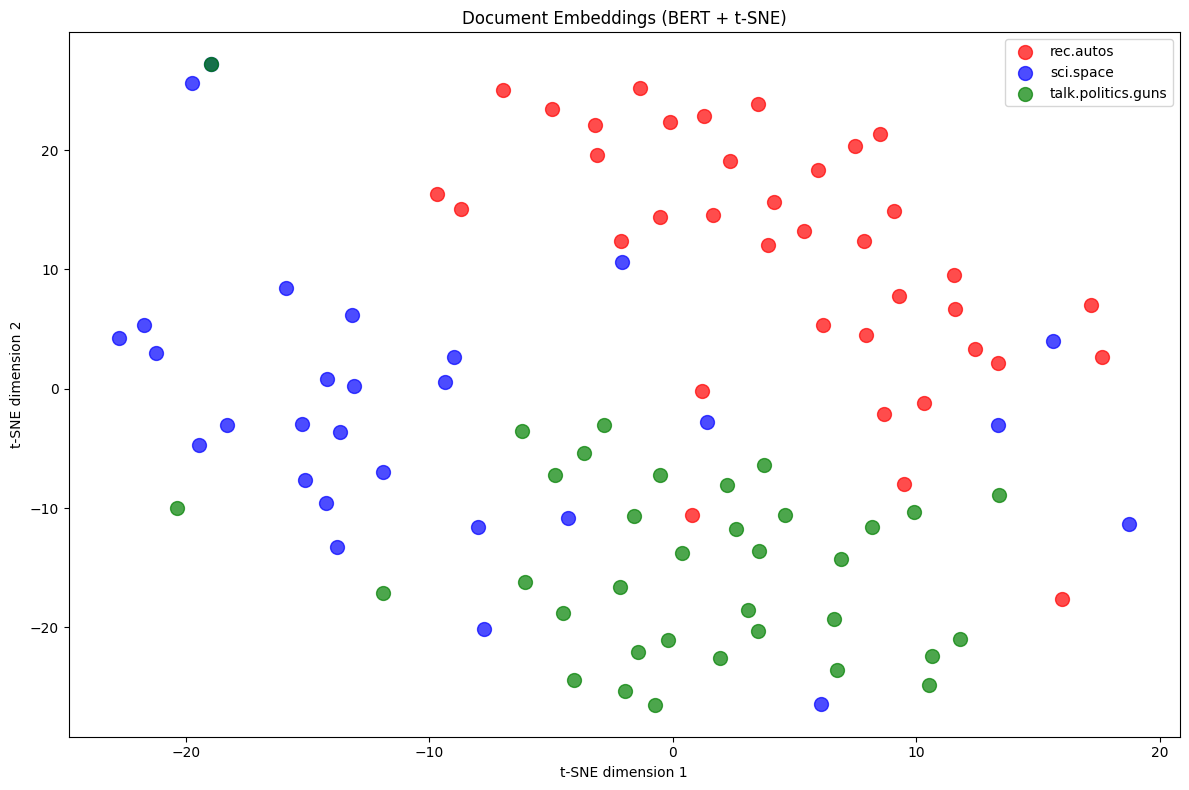

In [31]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {
    "rec.autos": "red",
    "sci.space": "blue",
    "talk.politics.guns": "green"
}

for category in my_categories:
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        color=colors[category],
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

D Written :

1. Cluster quality:  
The categories form reasonably distinct clusters, although there is still some overlap. This suggests that BERT embeddings capture useful semantic differences between the topics.

2. Misplaced documents:  
Yes, a few documents appear closer to another category. This could happen if the document contains mixed vocabulary or discusses a topic that overlaps with another category.

3. Most similar categories:  
The most similar categories seem to be rec.autos and talk.politics.guns, or sometimes rec.autos and sci.space depending on the sampled documents. This can happen when documents share discussion-style vocabulary even if the topics are different.

E Written question :

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple, easy to interpret, fast | Ignores context and semantics | Basic text classification, baseline models |
| TF-IDF | Highlights important words, reduces impact of common words | Still ignores deep semantics and context | Topic identification, document retrieval |
| Word2Vec | Learns semantic similarity between words | Needs enough training data, word-level only | Similar word analysis, domain vocabulary |
| GloVe | Strong general-purpose word embeddings | Not specific to my dataset, word-level only | General NLP tasks with common vocabulary |
| BERT | Captures context and semantic meaning very well | More computationally expensive | Semantic search, document classification, sentence similarity |

### 2. Best Method for My Dataset

For my dataset, BERT worked best overall because it captured semantic similarity better than the other methods. In the similarity heatmap, documents from the same categories were grouped more clearly than with TF-IDF in many cases. Semantic search also returned relevant documents even when the exact query words were not repeated in the text. Word2Vec was useful for exploring relationships between words, but it was more limited because the training dataset was much smaller than what is used for large pre-trained models. TF-IDF was still useful and interpretable, but it depended too much on direct word overlap.

### 3. My Recommendation for a Real System

If I were building a real document classification system, I would use BERT embeddings because they provide the richest representation of meaning and context. I would also compare them with TF-IDF as a strong baseline, since TF-IDF is much faster and easier to implement. For the final system, BERT would be my first choice if performance is more important than speed.